<p>
    <a href="https://umt.edu.al/en/anxhelo-shehu/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2022/10/Anxhelo-Shehu-min-2-300x300.jpg" width="150" alt="UMT Logo">
    </a>
</p>
<p>
    <a href="https://umt.edu.al/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2024/11/Universiteti-Metropolitan-Tirana.webp" width="200" alt="UMT Logo">
    </a>
</p>

<h1>Transformimi i Intensitetit dhe i Histogramse</h1>


Koha e nevojshme e percaktuar: **+50** minuta

<h2>Objectivat</h2>

Transformimet e pikselëve janë operacione që kryhen në piksel në një kohë. Në këtë laborator, do të filloni duke krijuar histograme. Histogramet shfaqin intensitetin e imazhit dhe mund të përdoren për të optimizuar karakteristikat e imazhit. Më pas, do të aplikoni Transformime të Intensitetit, duke bërë objektet më të lehta për t'u parë duke përmirësuar kontrastin dhe ndriçimin e imazhit. Në pjesën e fundit të laboratorit, do të përdorni përcaktimin e kufijve për të ndarë objektet nga imazhet.

<ul>
    <li><a href='#PT'>Transformimet e Pikselëve</a>
        <ul>
            <li>Histogrami</li>
            <li>Histogram Matching</li>
        </ul>
    </li>
</ul>


Shkarkojme imazhet e nevojshme per kete **Lab** (lejohet edhe perdorimi i imazheve te tjera)

In [1]:
import requests

# URL-te per imazhet
urls = [
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/goldhill.bmp",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/zelda.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/mammogram.png"
]

# Shkarkojme edhe ruajm imazhet duke perdorur URL-te perkatese
for url in urls:
    response = requests.get(url)
    if response.status_code == 200:
        filename = url.split("/")[-1]
        with open(filename, 'wb') as file:
            file.write(response.content)
        print(f"Shkarkuar: {filename}")
    else:
        print(f"Shkarkimi perfundoje: {url}")

Shkarkuar: lenna.png
Shkarkuar: baboon.png
Shkarkuar: goldhill.bmp
Shkarkuar: cameraman.jpeg
Shkarkuar: zelda.png
Shkarkuar: mammogram.png


 Per kete Lab do te perdorim keto funksione:

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

Le të definojmë një funksion ndihmës për të vizualizuar dy imazhe paralelishte.

In [3]:
def plot_image(image_1, image_2,title_1="Im.Origjinal", title_2="Imazhi i Ri"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    plt.show()

Definojmë një funksion tjetër ndihmës. Ky funksion do të vizualizojë dy histograma paralelishtë me nj-tj.

In [4]:
def plot_hist(old_image, new_image,title_old="Im.Origjinal", title_new="Imazhi i Ri"):
    intensity_values=np.array([x for x in range(256)])
    plt.subplot(1, 2, 1)
    plt.bar(intensity_values, cv2.calcHist([old_image],[0],None,[256],[0,256])[:,0],color='green', width = 5)
    plt.title(title_old)
    plt.xlabel('Intensiteti')
    plt.subplot(1, 2, 2)
    plt.bar(intensity_values, cv2.calcHist([new_image],[0],None,[256],[0,256])[:,0],color='red', width = 5)
    plt.title(title_new)
    plt.xlabel('Intensiteti')
    plt.show()

# Histograma

Një histogramë numëron numrin e shfaqjeve të vlerave të intensitetit të pikselëve dhe është një mjet i dobishëm për të kuptuar dhe manipuluar imazhe. Ne përdorim <code>cv.calcHist()</code> për të gjeneruar histogramën. Ja vlerat e parametrave:
<p>
    <code>cv2.calcHist(CV array:<b>[image]</b> ky është kanali i imazhit:<b>[0]</b>, për këtë kurs do të jetë gjithmonë <b>[None]</b>, numri i bins:<b>[L]</b>, diapazoni i indeksit të bins:<b>[0,L-1]</b>) </code>   
</p>
Për imazhe reale, <code>L</code> është <code>256</code>.

### Histogram matching
Histogram matching është një teknikë në përpunimin e imazheve që përdoret për të transformuar histogramin e një imazhi në mënyrë që të përputhet me histogramin e një imazhi tjetër referencë.

Le të jetë $f(x,y)$ imazhi origjinal dhe $g(x,y)$ imazhi i transformuar. Qëllimi është që shpërndarja e intensitetit të $g(x,y)$ të jetë e ngjashme me histogramin e një imazhi reference $r(x,y)$.

Procesi bazohet në funksionet kumulative të shpërndarjes (CDF):

$$
s = T(f) = CDF_f(f)
$$

dhe

$$
g = G^{-1}(s)
$$

ku:

- $CDF_f$ është funksioni kumulativ i histogramit të imazhit origjinal  
- $G^{-1}$ është funksioni invers i CDF të imazhit referencë  

Kjo lejon transformimin e intensiteteve të imazhit origjinal në mënyrë që histogrami i tij të përputhet me histogramin e imazhit referencë.


### Procesi teorik

Sipas Gonzalez & Woods (2017), për një imazh grayscale me intensitete \(r\) në intervalin \([0, L-1]\):

1. Llogaritet histogrami dhe pastaj PDF (Probability Density Function) e imazhit **source**:
$$
p_r(r_k) = \frac{n_k}{n} 
$$
ku \(n_k\) është numri i pixelëve me intensitet \(r_k\) dhe \(n\) është numri total i pixelëve.

2. Llogaritet **CDF (Cumulative Distribution Function)**:
$$
s = T(r) = \sum_{k=0}^{r} p_r(r_k)
$$

3. Përdoret CDF e imazhit reference \(G(z)\) për të gjetur intensitetin e përshtatur \(z\):
\[
z = G^{-1}(s)
\]

4. Kështu krijohet një **mapping** nga intensitetet e imazhit source në intensitetet e imazhit reference:
\[
r \longrightarrow s \longrightarrow z
\]

Ky proces garanton që histogrami i imazhit të përputhet me histogramin e reference.

#### Përmbledhje e hapave

1. Llogarit histogramin e imazhit source dhe reference  
2. Llogarit PDF dhe CDF për të dy imazhet  
3. Për çdo nivel intensiteti \(r\) të imazhit source, gjej intensitetin \(z\) më të afërt në CDF e reference  
4. Ndërto një **mapping** dhe apliko transformimin në të gjithë pixelët  
5. Rezultati është imazhi i përshtatur që ka histogramin e ngjashëm me reference

Ky algoritëm përdoret gjerësisht në përpunimin e imazheve mjekësore dhe aplikime të tjera ku është e rëndësishme të standardizohet ndriçimi apo kontrasti midis imazheve të ndryshme.

In [23]:
def histogram_matching(source, reference):

    # 1. Histogramet
    hist_src, _ = np.histogram(source.flatten(), 256, [0,256])
    hist_ref, _ = np.histogram(reference.flatten(), 256, [0,256])

    # 2. PDF
    pdf_src = hist_src / np.sum(hist_src)
    pdf_ref = hist_ref / np.sum(hist_ref)

    # 3. CDF
    cdf_src = np.cumsum(pdf_src)
    cdf_ref = np.cumsum(pdf_ref)

    # 4. krijo mapping r -> z
    mapping = np.zeros(256)

    for r in range(256):
        diff = np.abs(cdf_ref - cdf_src[r])
        mapping[r] = np.argmin(diff)

    # 5. aplikimi i transformimit
    matched = mapping[source]

    return matched.astype(np.uint8)

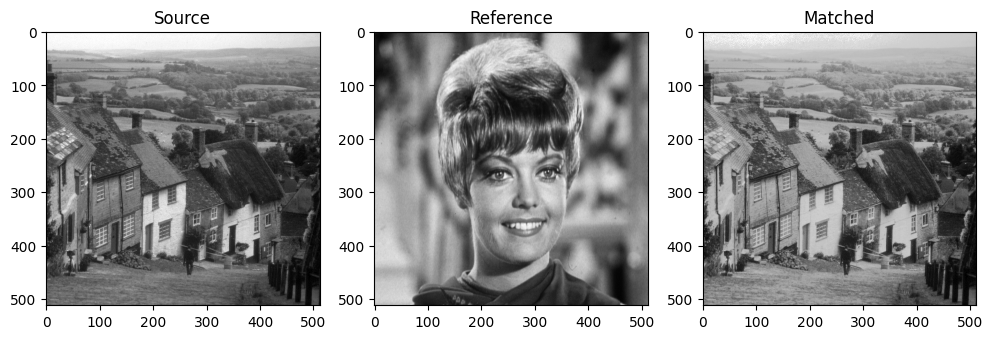

In [30]:
import cv2
import matplotlib.pyplot as plt

source = cv2.imread("goldhill.bmp",0)
reference = cv2.imread("zelda.png",0)

#source = cv2.imread("lenna.png", 0)
#reference = cv2.imread("goldhill.bmp", 0)

matched = histogram_matching(source, reference)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.title("Source")
plt.imshow(source,cmap='gray')

plt.subplot(132)
plt.title("Reference")
plt.imshow(reference,cmap='gray')

plt.subplot(133)
plt.title("Matched")
plt.imshow(matched,cmap='gray')

plt.show()

Function in python is ## exposure.match_histograms() ##  on lib 'skimage'

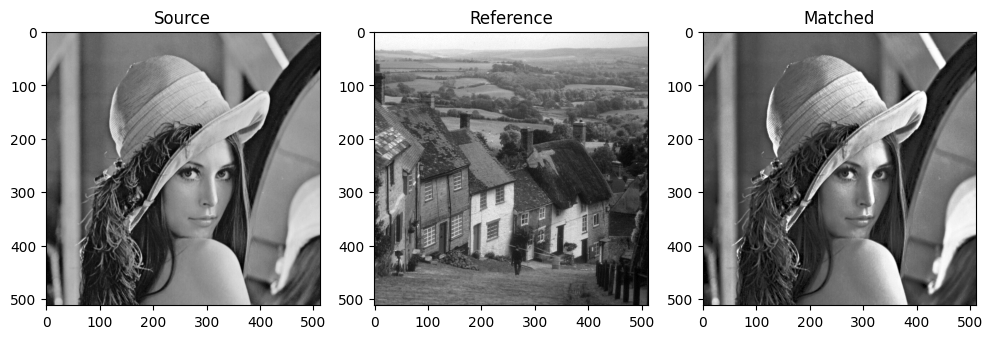

In [28]:
from skimage import exposure

# leximi i imazheve
source = cv2.imread("lenna.png", 0)
reference = cv2.imread("goldhill.bmp", 0)

# histogram matching
matched = exposure.match_histograms(source, reference)

# shfaqja
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Source")
plt.imshow(source, cmap='gray')

plt.subplot(1,3,2)
plt.title("Reference")
plt.imshow(reference, cmap='gray')

plt.subplot(1,3,3)
plt.title("Matched")
plt.imshow(matched, cmap='gray')

plt.show()

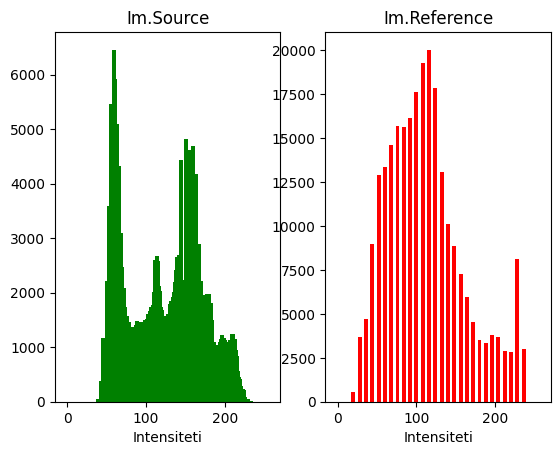

In [29]:
plot_hist(source, reference,title_old="Im.Source", title_new="Im.Reference")

error: OpenCV(4.8.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\histogram.cpp:1008: error: (-210:Unsupported format or combination of formats)  in function 'cv::calcHist'


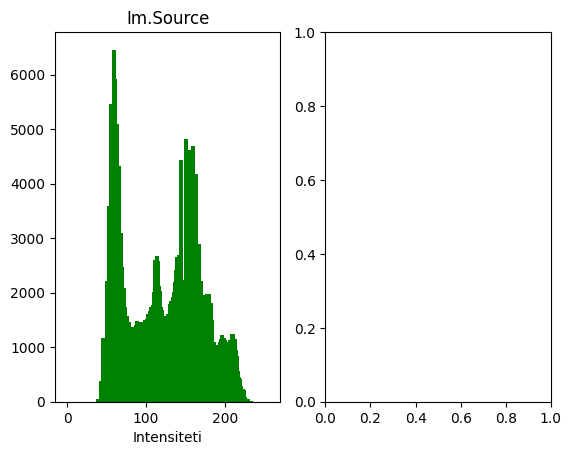

In [19]:
plot_hist(source, matched,title_old="Im.Source", title_new="Im.Matched")

In [18]:
matched

array([[144.77712742, 144.77712742, 143.619991  , ..., 154.1701365 ,
        131.97370835, 102.21191093],
       [144.77712742, 144.77712742, 143.619991  , ..., 154.1701365 ,
        131.97370835, 102.21191093],
       [144.77712742, 144.77712742, 143.619991  , ..., 154.1701365 ,
        131.97370835, 102.21191093],
       ...,
       [ 33.30739958,  33.30739958,  44.83831406, ...,  83.57369498,
         80.88126919,  82.24923234],
       [ 33.30739958,  33.30739958,  51.6851665 , ...,  85.82868452,
         86.83159132,  89.28567011],
       [ 33.30739958,  33.30739958,  51.6851665 , ...,  85.82868452,
         86.83159132,  89.28567011]])

In [17]:
matched2 = np.round(matched).astype(np.uint8)
matched2

array([[145, 145, 144, ..., 154, 132, 102],
       [145, 145, 144, ..., 154, 132, 102],
       [145, 145, 144, ..., 154, 132, 102],
       ...,
       [ 33,  33,  45, ...,  84,  81,  82],
       [ 33,  33,  52, ...,  86,  87,  89],
       [ 33,  33,  52, ...,  86,  87,  89]], dtype=uint8)

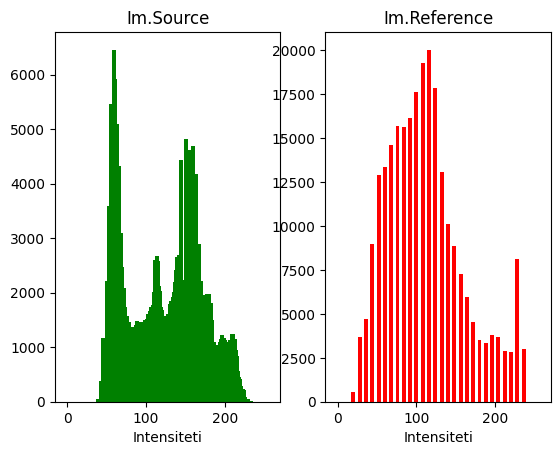

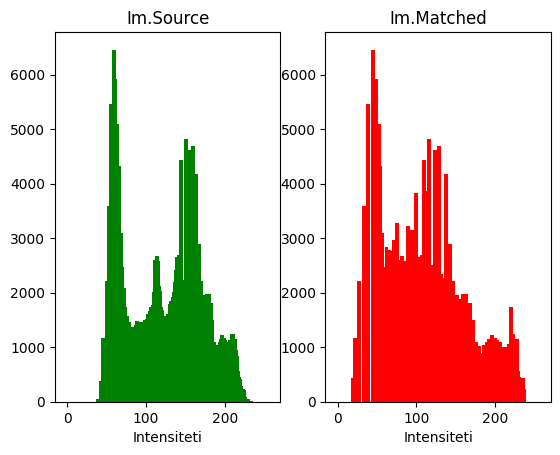

In [21]:
plot_hist(source, reference,title_old="Im.Source", title_new="Im.Reference")
plot_hist(source, matched2,title_old="Im.Source", title_new="Im.Matched")

# Referenca

[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<h3 align="center"> &#169; UMT. All rights reserved. <h3/>


## Ushtrim: 

**1)** Të shkarkohet një imazh (i ri i një kafshe të caktuar ose të përdoret imazhi i maces).  

**2)** Të llogaritet histogrami për imazhin me ngjyra.  

**3)** Të konvertohet në formatin bardh e zi dhe të llogaritet sërish histogrami.  

**4)** Të llogaritet probabiliteti për çdo intensitet.  

**5)** Të printohet imazhi negativ.  

**6)** Për imazhin pozitiv ose negativ, të vendoset një prag manualisht në bazë të histogramit dhe duke përdorur metodën e Otsu.  

Nje pjes e dokumentit eshte marre nga:
<p>
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>